# HỆ THỐNG XẾP HẠNG CV ĐA TẦNG (Composite Scoring Pipeline)
Dựa trên kiến trúc: `pipline/pipline_evaluate/composite_scoring_pipeline.md`
Mục tiêu: Đọc JSON Resume và JD, kết xuất bảng xếp hạng (.csv) với cơ chế Chặn đỉnh 100 điểm, Điểm Bonus vượt trần và Exp-weighted Jaccard.


## 1. Cài đặt Môi trường Google Colab


In [1]:
!pip install sentence-transformers tqdm


## 2. Kết nối Google Drive & Import Thư viện


In [2]:
import os
import json
import math
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import logging
from sentence_transformers import SentenceTransformer, util

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Cấu hình logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Khai báo đường dẫn Workspace gốc
BASE_DIR = '/content/drive/MyDrive/Nlp resume ranker'
RESUME_DIR = os.path.join(BASE_DIR, 'last_resumes')
JD_DIR = os.path.join(BASE_DIR, 'Cleaned_JD_V2')
CHROMA_DB_DIR = os.path.join(BASE_DIR, 'chroma_db')
OUTPUT_DIR = os.path.join(BASE_DIR, 'scoring')

os.makedirs(OUTPUT_DIR, exist_ok=True)
logger.info("Paths configured successfully.")


Mounted at /content/drive


## 3. Class Tiện ích: Phân tích Kỹ năng Mềm (Soft Skill Matcher)
Sử dụng SentenceTransformers để kiểm tra Semantic Match giữa JD và CV (Ngưỡng 0.75).


In [3]:
class SoftSkillMatcher:
    def __init__(self, model_name='all-MiniLM-L6-v2', threshold=0.55):
        self.model = SentenceTransformer(model_name)
        self.threshold = threshold
        logger.info(f"Loaded Semantic Model: {model_name}")

    def count_matches(self, jd_soft_skills, cv_soft_skills):
        if not jd_soft_skills or not cv_soft_skills:
            return 0

        cv_texts = []
        for s in cv_soft_skills:
            if isinstance(s, dict):
                cv_texts.append(s.get('skill', ''))
            else:
                cv_texts.append(str(s))

        jd_embeddings = self.model.encode(jd_soft_skills, convert_to_tensor=True)
        cv_embeddings = self.model.encode(cv_texts, convert_to_tensor=True)

        cosine_scores = util.cos_sim(cv_embeddings, jd_embeddings)

        match_count = 0
        for i in range(len(cv_texts)):
            # Nếu skill CV này có điểm cos_sim > threshold với BAT KY skill nào trong JD
            if torch.max(cosine_scores[i]).item() > self.threshold:
                match_count += 1

        return match_count


## 4. Lõi Chấm Điểm Tuyển Dụng (Composite Scoring Engine)
Cài đặt chính xác các thuật toán Toán học trong đặc tả Benchmark SOTA.


In [4]:
class CompositeScorer:
    def __init__(self):
        # Trọng số Cốt lõi (Tổng 100%)
        self.W_HARD = 0.8
        self.W_CONSTRAINTS = 0.2

        # Trọng số Rổ kỹ năng
        self.W_MUST_HAVE = 1.0
        self.W_NICE_TO_HAVE = 0.7
        self.W_EXPANSION = 0.3
        self.W_SURPLUS = 0.05

        # Trọng số Thưởng (Vượt trần)
        self.B_SOFT = 1.0
        self.B_CERT = 1.0

    def _get_degree_rank(self, degree_str):
        if not degree_str: return 0
        s = str(degree_str).lower()
        if any(x in s for x in ['phd', 'doctor', 'tiến sĩ']): return 3
        if any(x in s for x in ['master', 'm.s', 'm.a', 'thạc sĩ']): return 2
        if any(x in s for x in ['bachelor', 'b.s', 'b.a', 'cử nhân']): return 1
        return 0

    def _process_constraints(self, jd_data, cv_data):
        # Bảo vệ null fallback bằng cách ép `or {}`
        jd_const = jd_data.get('Hard_Constraints') or {}
        cv_info = cv_data.get('Information') or {}
        cv_edu = cv_data.get('Education') or {}

        # Xử lý Years of Experience chống null và chữ
        jd_yoe = jd_const.get('Min_Experience_Years')
        jd_yoe = float(jd_yoe) if jd_yoe is not None else 0.0

        cv_yoe = cv_info.get('Years_of_Exp')
        cv_yoe = float(cv_yoe) if cv_yoe is not None else 0.0

        # Xử lý bằng cấp chống null
        jd_deg = jd_const.get('Required_Degree') or ''
        cv_deg = cv_edu.get('Degree') or ''

        score_yoe = 1.0 if cv_yoe >= jd_yoe else 0.0
        score_deg = 1.0 if self._get_degree_rank(cv_deg) >= self._get_degree_rank(jd_deg) else 0.0

        return (score_yoe * 0.5) + (score_deg * 0.5)

    def evaluate(self, jd_data, cv_data, soft_match_count=0):
        # 1. TÍNH TOÁN MAX IDEAL SCORE (Bảo vệ null bằng `or {}`, `or []`)
        jd_hard = jd_data.get('Hard_Skills') or {}

        must_have = (jd_hard.get('Must_Have') or {}).get('Tech_Skills') or []
        nice_have = (jd_hard.get('Nice_To_Have') or {}).get('From_JD_Desirable') or []
        expansion = (jd_hard.get('Nice_To_Have') or {}).get('From_Taxonomy_Expansion') or []

        # Lấy số năm kinh nghiệm dự kiến (chống null)
        jd_const = jd_data.get('Hard_Constraints') or {}
        try:
            min_exp = jd_const.get('Min_Experience_Years')
            ideal_years = float(min_exp) if min_exp is not None else 0.0
            if math.isnan(ideal_years) or ideal_years < 0:
                ideal_years = 0.0
        except (ValueError, TypeError):
            ideal_years = 0.0

        ideal_multiplier = 1.0 + math.log(ideal_years + 1.0)

        max_score = 0.0
        max_score += len(must_have) * self.W_MUST_HAVE * ideal_multiplier
        max_score += len(nice_have) * self.W_NICE_TO_HAVE * ideal_multiplier
        max_score += len(expansion) * self.W_EXPANSION * ideal_multiplier

        if max_score == 0: max_score = 1.0 # Tránh chia 0

        # 2. TÍNH ĐIỂM KỸ NĂNG ỨNG VIÊN
        cv_hard = cv_data.get('Hard_Skills') or {}
        cv_skills = cv_hard.get('Direct_Mention') or []

        mh_set = set(x.lower() for x in must_have)
        nh_set = set(x.lower() for x in nice_have)
        ex_set = set(x.lower() for x in expansion)

        cand_hard_score = 0.0
        cand_surplus_score = 0.0

        for sk in cv_skills:
            if not isinstance(sk, dict):
                continue # Bỏ qua nếu skill không phải object hợp lệ

            raw_name = (sk.get('skill') or '').lower()
            tax_id = sk.get('taxonomy_id')
            # Trích xuất tên chuẩn hóa từ taxonomy_id (VD: "Data.RDBMS_oracle db" -> "oracle db")
            norm_name = tax_id.split('_')[-1].lower() if tax_id else raw_name

            years = sk.get('years')
            years = float(years) if years is not None else 0.0
            multiplier = 1.0 + math.log(years + 1.0)

            # Quét match dựa trên cả [Tên chuẩn hóa từ Taxonomy] VÀ [Tên gốc]
            if (norm_name and norm_name in mh_set) or (raw_name and raw_name in mh_set):
                cand_hard_score += self.W_MUST_HAVE * multiplier
                mh_set.discard(norm_name)
                mh_set.discard(raw_name)
            elif (norm_name and norm_name in nh_set) or (raw_name and raw_name in nh_set):
                cand_hard_score += self.W_NICE_TO_HAVE * multiplier
                nh_set.discard(norm_name)
                nh_set.discard(raw_name)
            elif (norm_name and norm_name in ex_set) or (raw_name and raw_name in ex_set):
                cand_hard_score += self.W_EXPANSION * multiplier
                ex_set.discard(norm_name)
                ex_set.discard(raw_name)
            else:
                cand_surplus_score += self.W_SURPLUS * multiplier # Gọi riêng vào thang Bonus

        # 3. CHUẨN HÓA VÀ TRÀN ĐIỂM (CAP & SPILLOVER)
        hard_ratio = cand_hard_score / max_score
        capped_ratio = min(hard_ratio, 1.0)
        overflow_ratio = max(0.0, hard_ratio - 1.0)

        # 4. RÀNG BUỘC
        constraint_score = self._process_constraints(jd_data, cv_data)

        # 5. GHÉP BASE SCORE (MAX 100)
        base_score = (capped_ratio * self.W_HARD * 100) + (constraint_score * self.W_CONSTRAINTS * 100)

        # 6. ĐIỂM THƯỞNG BONUS
        overqualified_bonus = overflow_ratio * self.W_HARD * 100
        soft_bonus = soft_match_count * self.B_SOFT

        cv_certs = cv_hard.get('Certifications') or [] # Lấy danh sách chứng chỉ an toàn (chống null)
        cert_count = len(cv_certs)
        cert_bonus = cert_count * self.B_CERT

        total_bonus = overqualified_bonus + soft_bonus + cert_bonus + cand_surplus_score
        final_score = base_score + total_bonus

        return {
            'Base_Score': round(base_score, 2),
            'Bonus_Score': round(total_bonus, 2),
            'Total_Score': round(final_score, 2),
            'Is_Overqualified': overflow_ratio > 0
        }

## 5. Khởi tạo Engine Chấm Điểm


In [5]:
import torch # for soft skill matcher

# Khởi tạo Engine
soft_matcher = SoftSkillMatcher()
engine = CompositeScorer()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 6. Mẫu Test Một Chạm (Tùy chọn)
Giúp quan sát đầu ra rõ ràng trước khi chạy hàng loạt. Bạn có thể bỏ qua block này nếu muốn chạy luôn Batch Pipeline.


In [6]:
# Lấy thử 1 JD và 1 CV
try:
    sample_jd_path = os.path.join(JD_DIR, os.listdir(JD_DIR)[0])
    sample_cv_path = os.path.join(RESUME_DIR, os.listdir(RESUME_DIR)[0])

    with open(sample_jd_path, 'r', encoding='utf-8') as f:
        jd_test = json.load(f)
    with open(sample_cv_path, 'r', encoding='utf-8') as f:
        cv_test = json.load(f)

    jd_soft = jd_test.get('Soft_Skills', [])
    cv_soft = cv_test.get('Soft_Skills', [])

    match_count = soft_matcher.count_matches(jd_soft, cv_soft)
    res = engine.evaluate(jd_test, cv_test, soft_match_count=match_count)

    print(f"\nTESTING REPORT")
    print(f"JD: {os.path.basename(sample_jd_path)}")
    print(f"CV: {os.path.basename(sample_cv_path)}")
    print(f"Base Score: {res['Base_Score']}/100")
    print(f"Bonus Score: +{res['Bonus_Score']}")
    print(f"Final Score: {res['Total_Score']}")

except Exception as e:
    logger.error(f"Test failed: {e}")



TESTING REPORT
JD: JD_BA_1_cleaned.json
CV: Adelina_Erimia_PMP1.json
Base Score: 35.85/100
Bonus Score: +4.52
Final Score: 40.36


## 7. Chạy Hàng Loạt & Xuất CSV (Batch Pipeline)


In [7]:
def process_all(jd_dir, cv_dir, output_dir):
    jds = []
    for f in os.listdir(jd_dir):
        if f.endswith('.json'):
            path = os.path.join(jd_dir, f)
            try:
                with open(path, 'r', encoding='utf-8') as file:
                    jds.append({"name": f.replace('.json', ''), "data": json.load(file)})
            except: continue

    cv_files = [f for f in os.listdir(cv_dir) if f.endswith('.json')]

    results = []
    # Dict lưu trữ kết quả chi tiết từng JD
    jd_specific_results = {jd['name']: [] for jd in jds}

    for cv_f in tqdm(cv_files, desc="Ranking Resumes"):
        cv_path = os.path.join(cv_dir, cv_f)
        try:
            with open(cv_path, 'r', encoding='utf-8') as file:
                cv_data = json.load(file)
        except Exception as e:
            logger.warning(f"Failed to read {cv_f}: {e}")
            continue

        cv_name = cv_f.replace('.json', '')
        row = {'file_name': cv_name}

        # Bảo vệ null fallback: Nếu Soft_Skills bị gán `null`, đưa về mảng rỗng []
        cv_soft_skills = cv_data.get('Soft_Skills') or []

        for jd in jds:
            jd_soft = jd['data'].get('Soft_Skills') or []
            jd_name = jd['name']
            try:
                match_count = soft_matcher.count_matches(jd_soft, cv_soft_skills)
                res = engine.evaluate(jd['data'], cv_data, soft_match_count=match_count)

                # Ghi nhận vào bảng tổng
                row[jd_name] = res['Total_Score']

                # Ghi nhận chi tiết vào bảng riêng của JD đó
                jd_specific_results[jd_name].append({
                    'file_name': cv_name,
                    'Base Score': res['Base_Score'],
                    'Bonus Score': res['Bonus_Score'],
                    'Final Score': res['Total_Score']
                })

            except Exception as e:
                row[jd_name] = 0.0
                jd_specific_results[jd_name].append({
                    'file_name': cv_name,
                    'Base Score': 0.0,
                    'Bonus Score': 0.0,
                    'Final Score': 0.0
                })

        results.append(row)

    # Bảng tổng hợp chứa tất cả JD
    df_main = pd.DataFrame(results)
    out_path_main = os.path.join(output_dir, 'final_ranking_scores.csv')
    df_main.to_csv(out_path_main, index=False)
    logger.info(f"Đã lưu bảng tổng hợp: {out_path_main}")

    # Bảng chi tiết cho từng JD
    for jd_name, rows in jd_specific_results.items():
        df_jd = pd.DataFrame(rows)
        df_jd = df_jd.sort_values(by='Final Score', ascending=False)
        out_path_jd = os.path.join(output_dir, f"{jd_name}_ranking_scores.csv")
        df_jd.to_csv(out_path_jd, index=False)

    logger.info(f"Hoàn thành! Đã tạo thêm {len(jds)} file CSV chi tiết theo JD.")
    return df_main

# Khởi chạy Pipeline
df_result = process_all(JD_DIR, RESUME_DIR, OUTPUT_DIR)
# df_result.head()

Ranking Resumes:   0%|          | 0/228 [00:00<?, ?it/s]

# Thống kê

In [8]:
import os

# Liệt kê các file csv trong thư mục scoring
if os.path.exists(OUTPUT_DIR):
    csv_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.csv')]
    print(f"Tìm thấy {len(csv_files)} file CSV trong {OUTPUT_DIR}:")
    for f in csv_files:
        print(f" - {f}")
else:
    print(f"Thư mục {OUTPUT_DIR} không tồn tại.")

Tìm thấy 18 file CSV trong /content/drive/MyDrive/Nlp resume ranker/scoring:
 - final_ranking_scores.csv
 - JD_BA_1_cleaned_ranking_scores.csv
 - JD_BA_2_cleaned_ranking_scores.csv
 - JD_SW_1_cleaned_ranking_scores.csv
 - JD_SW_2_cleaned_ranking_scores.csv
 - JD_SW_3_cleaned_ranking_scores.csv
 - JD_SW_5_cleaned_ranking_scores.csv
 - JD_SW_6_cleaned_ranking_scores.csv
 - JD_PM_2_cleaned_ranking_scores.csv
 - JD_SM_2_cleaned_ranking_scores.csv
 - JD_DA_DE_1_cleaned_ranking_scores.csv
 - JD_DA_DE_2_cleaned_ranking_scores.csv
 - JD_DA_DE_3_cleaned_ranking_scores.csv
 - JD_BA_3_cleaned_ranking_scores.csv
 - JD_BA_4_cleaned_ranking_scores.csv
 - JD_PM_1_cleaned_ranking_scores.csv
 - JD_SM_1_cleaned_ranking_scores.csv
 - JD_SW_4_cleaned_ranking_scores.csv


In [9]:
import pandas as pd
import os

# 1. Đọc tệp tin tổng hợp final_ranking_scores.csv
main_csv_path = os.path.join(OUTPUT_DIR, 'final_ranking_scores.csv')
df_main = pd.read_csv(main_csv_path)

# 2. Hiển thị 5 dòng đầu tiên của df_main
print("--- Cấu trúc file tổng hợp (df_main) ---")
display(df_main.head())

# 3 & 4. Đọc các tệp tin chi tiết JD tiêu biểu (BA và SW)
ba_detail_path = os.path.join(OUTPUT_DIR, 'JD_BA_1_cleaned_ranking_scores.csv')
sw_detail_path = os.path.join(OUTPUT_DIR, 'JD_SW_1_cleaned_ranking_scores.csv')

if os.path.exists(ba_detail_path):
    df_ba_detail = pd.read_csv(ba_detail_path)
    print("\n--- Chi tiết xếp hạng JD_BA_1 ---")
    display(df_ba_detail.head())

if os.path.exists(sw_detail_path):
    df_sw_detail = pd.read_csv(sw_detail_path)
    print("\n--- Chi tiết xếp hạng JD_SW_1 ---")
    display(df_sw_detail.head())

print(f"\nTổng cộng có {len(df_main)} ứng viên được xếp hạng.")

--- Cấu trúc file tổng hợp (df_main) ---


,file_name,JD_BA_1_cleaned,JD_BA_2_cleaned,JD_SW_1_cleaned,JD_SW_2_cleaned,JD_SW_3_cleaned,JD_SW_5_cleaned,JD_SW_6_cleaned,JD_PM_2_cleaned,JD_SM_2_cleaned,JD_DA_DE_1_cleaned,JD_DA_DE_2_cleaned,JD_DA_DE_3_cleaned,JD_BA_3_cleaned,JD_BA_4_cleaned,JD_PM_1_cleaned,JD_SM_1_cleaned,JD_SW_4_cleaned
0,Adelina_Erimia_PMP1,40.36,21.66,14.79,24.79,14.79,24.79,33.62,39.73,64.88,14.79,39.98,14.79,24.79,20.63,14.79,30.27,24.79
1,Jennifer M. Conte,47.25,30.25,43.30,77.61,119.76,54.27,86.77,30.25,33.22,42.87,41.23,114.23,30.25,35.82,30.25,30.25,105.92
2,Othman - Project Manager,64.09,43.38,28.64,29.23,31.34,28.33,42.51,84.93,58.23,26.02,26.91,27.78,25.91,27.41,44.05,62.68,31.83
3,Resume2018March,22.66,12.66,12.66,28.56,19.02,38.33,27.13,22.66,22.66,15.00,12.66,20.13,22.66,14.31,12.66,22.66,80.46
4,Randy Adams,69.28,49.99,41.25,68.75,79.05,44.68,83.15,76.15,70.71,40.56,54.66,86.84,33.74,42.41,33.74,57.55,76.54



--- Chi tiết xếp hạng JD_BA_1 ---


,file_name,Base Score,Bonus Score,Final Score
0,Candidate 62 Sr. BSA Resume,98.62,9.71,108.33
1,Candidate_06BSA,96.74,9.72,106.46
2,Candidate71 health care resume,99.52,3.93,103.45
3,Candidate_03 - SM,92.39,9.21,101.60
4,Candidate141,88.81,12.78,101.59



--- Chi tiết xếp hạng JD_SW_1 ---


,file_name,Base Score,Bonus Score,Final Score
0,Candidate133 EDA,39.58,12.76,52.34
1,Candidate108,39.08,11.67,50.75
2,Candidate67,39.64,9.72,49.37
3,Candidate80,35.10,13.87,48.97
4,Candidate29_Project Manager_1,34.79,13.35,48.14



Tổng cộng có 228 ứng viên được xếp hạng.


**Reasoning**:
I will calculate the descriptive statistics for all Job Description (JD) columns in the `df_main` DataFrame, excluding the 'file_name' column, and transpose the result for better readability.



In [10]:
# Calculate descriptive statistics for JD columns
# Exclude 'file_name' to focus on numeric scores
jd_stats = df_main.drop(columns=['file_name']).describe().T

# Adding a title for clarity
print("--- Descriptive Statistics for Job Descriptions (Transposed) ---")
display(jd_stats)

# Optional: display specific metrics if needed
print("\nSummary of Mean Scores per JD:")
print(jd_stats['mean'].sort_values(ascending=False))

--- Descriptive Statistics for Job Descriptions (Transposed) ---


,count,mean,std,min,25%,50%,75%,max
JD_BA_1_cleaned,228.0,56.107061,20.878229,20.00,39.3350,54.405,70.3200,108.33
JD_BA_2_cleaned,228.0,38.341754,12.226459,6.36,29.9000,39.460,47.4225,68.46
JD_SW_1_cleaned,228.0,31.960965,9.370014,5.57,27.0575,32.750,38.7100,52.34
JD_SW_2_cleaned,228.0,50.738816,14.794844,10.00,39.1650,51.750,62.4650,88.31
JD_SW_3_cleaned,228.0,53.485439,23.278001,12.36,30.9175,53.010,73.3175,119.76
JD_SW_5_cleaned,228.0,37.440789,10.269863,10.00,28.7975,35.425,46.1925,67.78
JD_SW_6_cleaned,228.0,62.436360,17.152794,20.00,50.9050,61.280,73.5925,104.45
JD_PM_2_cleaned,228.0,71.918289,26.007096,20.00,51.8100,72.050,88.3550,152.60
JD_SM_2_cleaned,228.0,69.482544,27.317703,20.00,48.3750,65.845,87.8750,135.83
JD_DA_DE_1_cleaned,228.0,33.198333,8.219180,10.00,27.7875,33.155,39.2400,54.48



Summary of Mean Scores per JD:
JD_PM_2_cleaned       71.918289
JD_SM_2_cleaned       69.482544
JD_SW_6_cleaned       62.436360
JD_SM_1_cleaned       61.965789
JD_BA_1_cleaned       56.107061
JD_DA_DE_3_cleaned    54.918596
JD_SW_3_cleaned       53.485439
JD_SW_4_cleaned       53.199781
JD_SW_2_cleaned       50.738816
JD_DA_DE_2_cleaned    41.144167
JD_BA_2_cleaned       38.341754
JD_SW_5_cleaned       37.440789
JD_DA_DE_1_cleaned    33.198333
JD_BA_4_cleaned       32.295000
JD_SW_1_cleaned       31.960965
JD_BA_3_cleaned       29.287851
JD_PM_1_cleaned       28.195965
Name: mean, dtype: float64


## Analyze Score Distributions for 17 JDs

### Subtask:
Load individual JD ranking files and visualize the distribution of Base and Bonus scores using a grid of histograms.


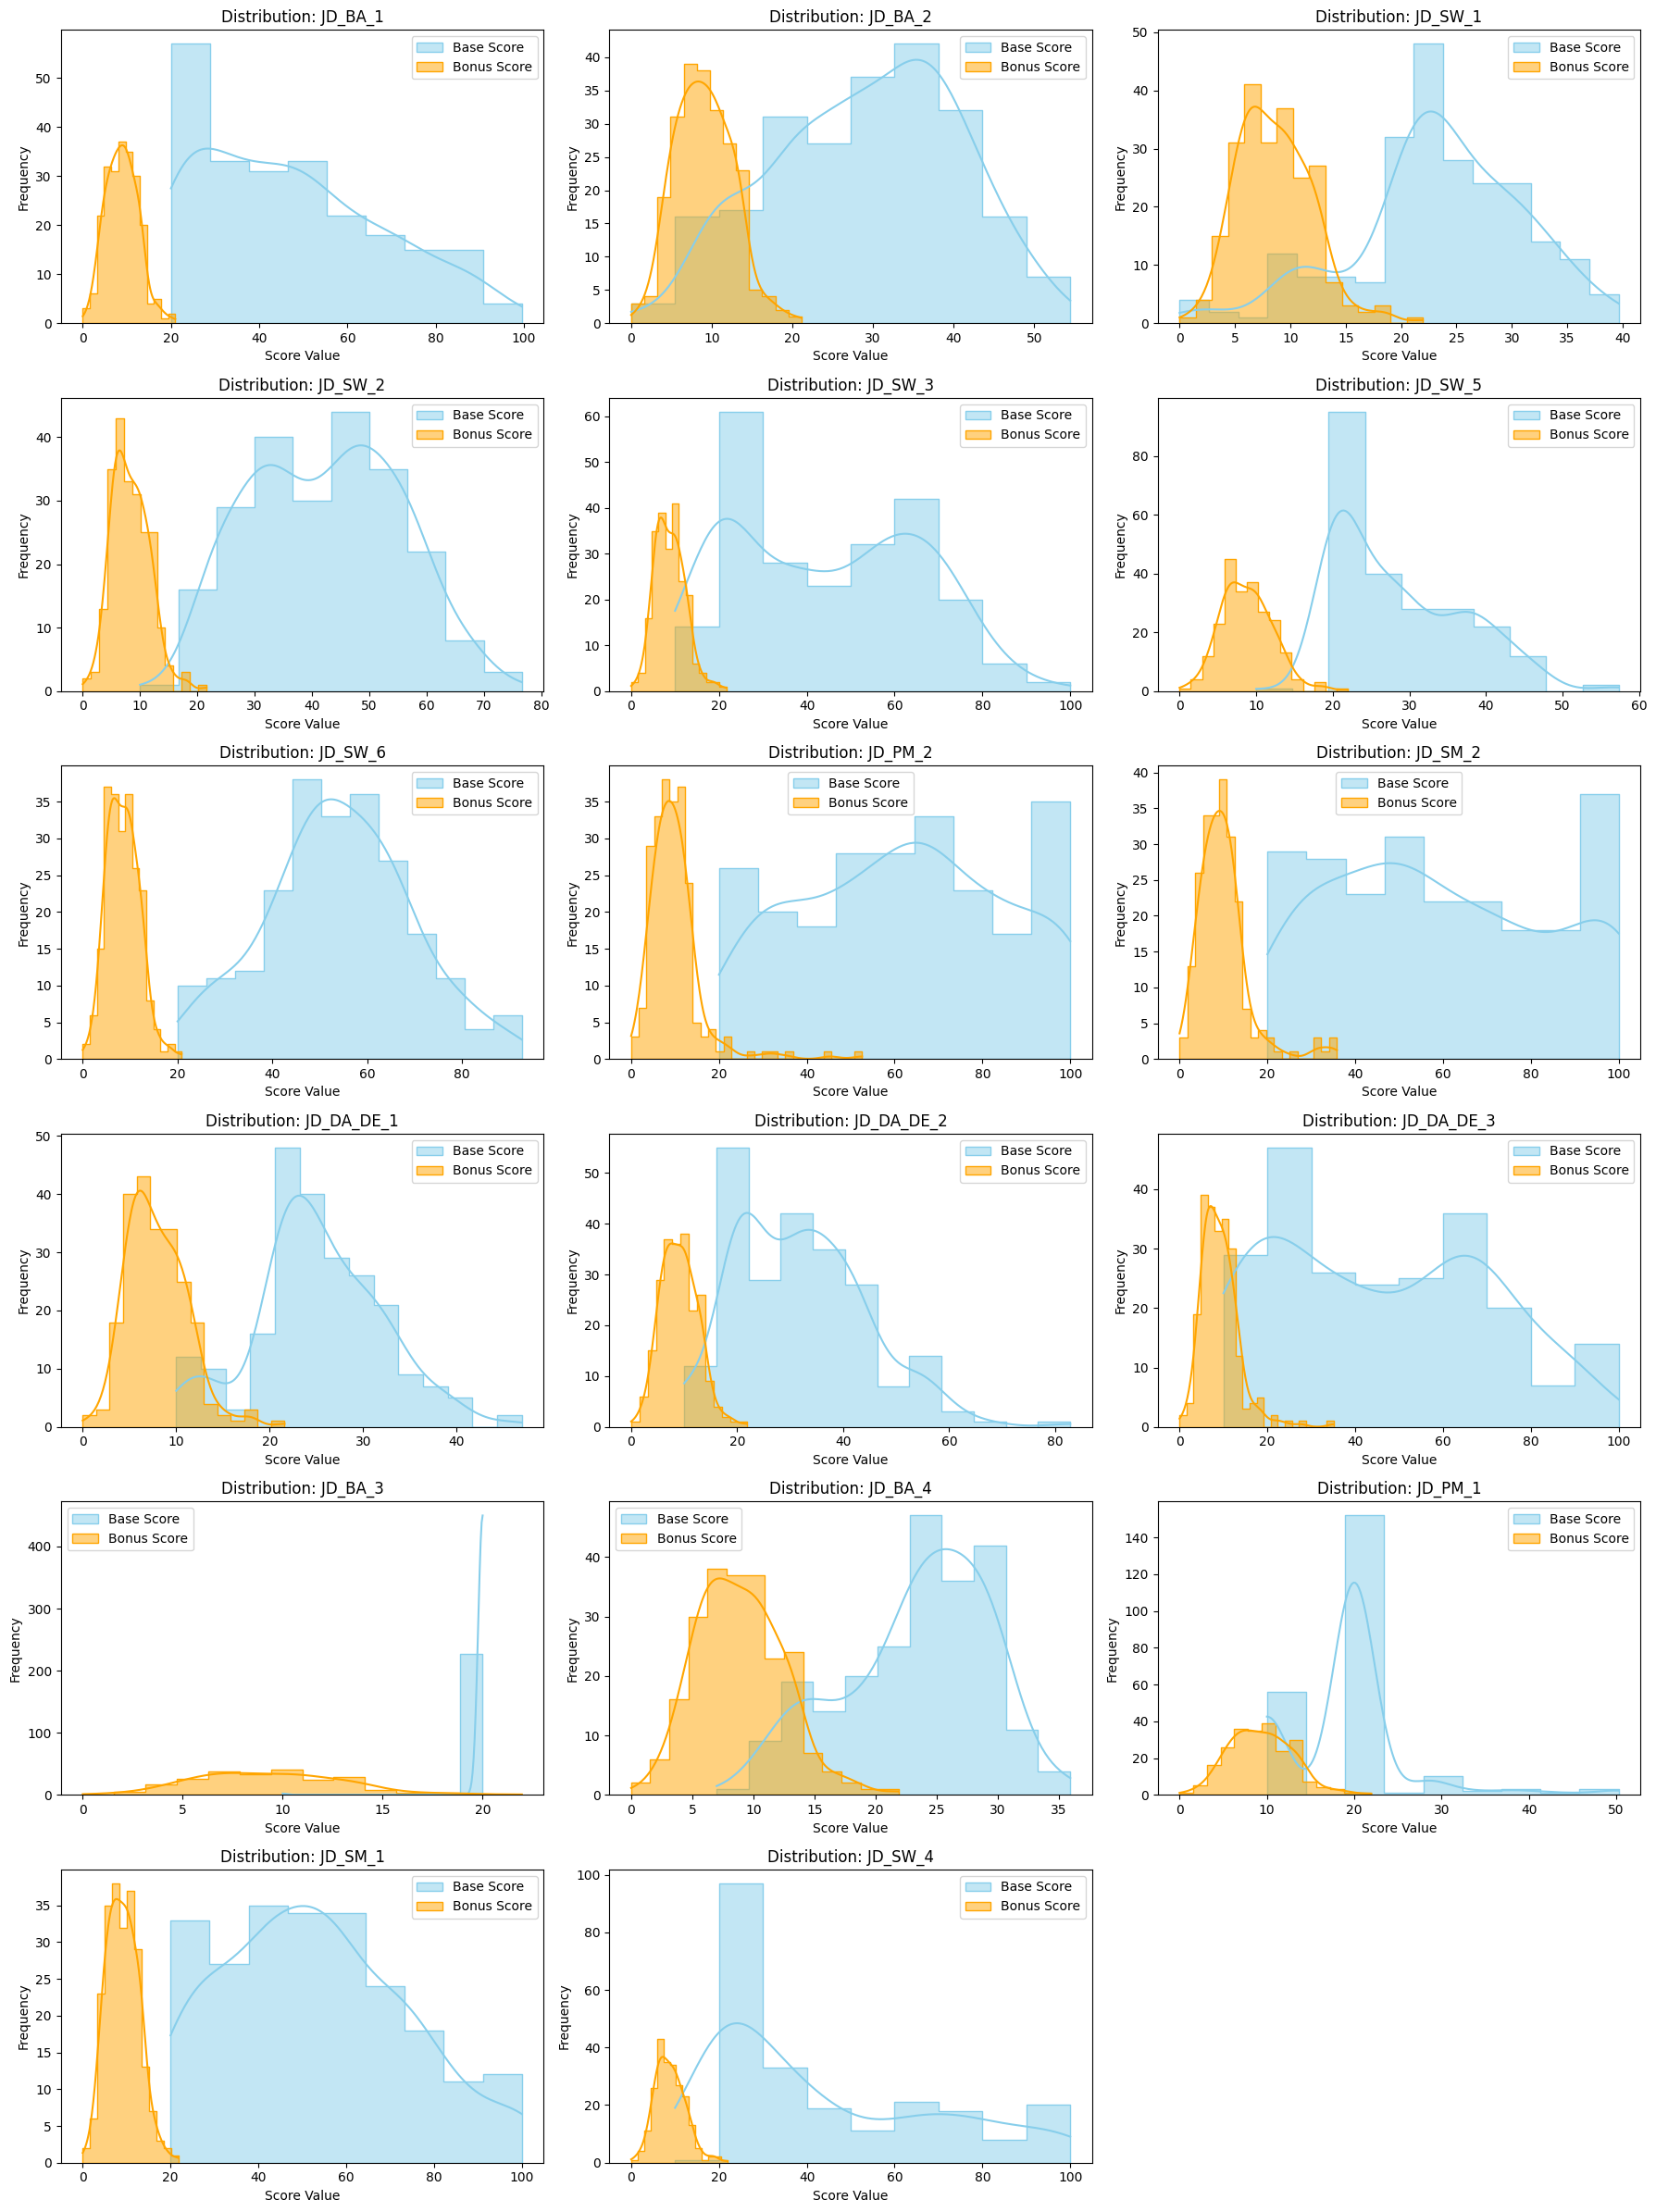

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# 1. Filter the csv_files list to exclude 'final_ranking_scores.csv'
# Note: csv_files was defined in a previous cell
individual_jd_files = [f for f in csv_files if f != 'final_ranking_scores.csv']

# 2. Create a figure with a 6x3 grid of subplots (18 slots for 17 JDs)
fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

# 3. Iterate through the filtered list of CSV files
for i, file_name in enumerate(individual_jd_files):
    file_path = os.path.join(OUTPUT_DIR, file_name)
    df_jd = pd.read_csv(file_path)

    jd_label = file_name.replace('_ranking_scores.csv', '').replace('_cleaned', '')

    # 4. Plot overlapping histograms for Base and Bonus scores
    sns.histplot(df_jd['Base Score'], color='skyblue', label='Base Score', kde=True, ax=axes[i], element='step')
    sns.histplot(df_jd['Bonus Score'], color='orange', label='Bonus Score', kde=True, ax=axes[i], element='step')

    axes[i].set_title(f"Distribution: {jd_label}", fontsize=12)
    axes[i].set_xlabel("Score Value")
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

# 5. Hide the empty 18th subplot
if len(axes) > len(individual_jd_files):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

## Compare Average Final Scores Across Roles

### Subtask:
Create a bar chart comparing the mean Final Score of each of the 17 JDs to identify which roles have the strongest candidate matches overall.


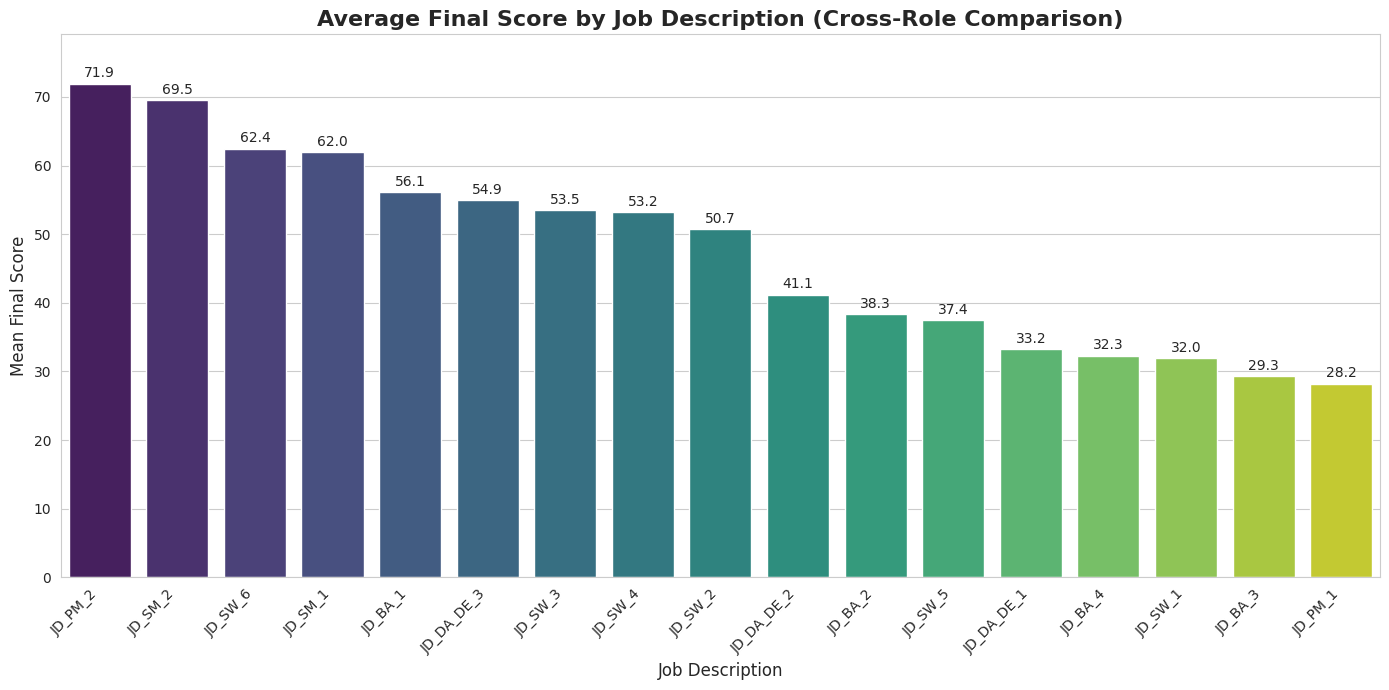

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. & 2. Extract mean scores from jd_stats and sort descending
mean_scores = jd_stats['mean'].sort_values(ascending=False)

# 3. Clean index labels (remove '_cleaned' or '_ranking_scores')
clean_labels = [label.replace('_cleaned', '').replace('_ranking_scores', '') for label in mean_scores.index]

# 4. Create the bar chart
plt.figure(figsize=(14, 7))
sns.set_style('whitegrid')
barplot = sns.barplot(x=clean_labels, y=mean_scores.values, palette='viridis', hue=clean_labels, legend=False)

# 5. Add titles and labels
plt.title('Average Final Score by Job Description (Cross-Role Comparison)', fontsize=16, fontweight='bold')
plt.xlabel('Job Description', fontsize=12)
plt.ylabel('Mean Final Score', fontsize=12)

# 6. Rotate labels and adjust layout
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(mean_scores.values) * 1.1)  # Add some headroom for labels if needed

# Add value labels on top of bars
for i, v in enumerate(mean_scores.values):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Identify Best and Worst Overall Candidates

### Subtask:
Calculate the average Final Score for every candidate across all 17 JDs to identify and display the top-performing and lowest-performing candidates.


In [15]:
# 1. Tính toán điểm trung bình cho mỗi ứng viên trên 17 JD
# Loại bỏ cột 'file_name' để chỉ lấy các cột điểm số
jd_columns = df_main.drop(columns=['file_name'])
candidate_summary = pd.DataFrame({
    'Ứng viên': df_main['file_name'],
    'Điểm Trung Bình': jd_columns.mean(axis=1),
    'Điểm Cao Nhất': jd_columns.max(axis=1),
    'Vị trí Phù hợp nhất': jd_columns.idxmax(axis=1)
})

# 2. Sắp xếp để tìm Top & Bottom
candidate_summary = candidate_summary.sort_values(by='Điểm Trung Bình', ascending=False)

print("--- THỐNG KÊ CHI TIẾT ỨNG VIÊN (Trên 17 JD) ---")
print(f"\n1. Top 5 Ứng viên có năng lực bao quát tốt nhất:")
display(candidate_summary.head(5))

print(f"\n2. 5 Ứng viên có điểm thấp nhất (Cần xem lại hồ sơ):")
display(candidate_summary.tail(5))

# 3. Thống kê tổng quan
top_one = candidate_summary.iloc[0]
print(f"\n=> Kết luận: Ứng viên xuất sắc nhất là {top_one['Ứng viên']} với điểm trung bình {top_one['Điểm Trung Bình']:.2f}.")
print(f"Người này phù hợp nhất với vị trí: {top_one['Vị trí Phù hợp nhất']} (Điểm: {top_one['Điểm Cao Nhất']:.2f})")

--- THỐNG KÊ CHI TIẾT ỨNG VIÊN (Trên 17 JD) ---

1. Top 5 Ứng viên có năng lực bao quát tốt nhất:


,Ứng viên,Điểm Trung Bình,Điểm Cao Nhất,Vị trí Phù hợp nhất
119,Candidate108,70.280000,114.08,JD_SW_4_cleaned
212,candidate197java,68.365294,115.11,JD_SW_4_cleaned
91,Candidate80,66.961176,113.61,JD_SW_4_cleaned
109,Candidate98 Resume,66.873529,135.38,JD_PM_2_cleaned
38,Candidate29_Project Manager_1,66.861765,105.64,JD_PM_2_cleaned



2. 5 Ứng viên có điểm thấp nhất (Cần xem lại hồ sơ):


,Ứng viên,Điểm Trung Bình,Điểm Cao Nhất,Vị trí Phù hợp nhất
0,Adelina_Erimia_PMP1,27.308235,64.88,JD_SM_2_cleaned
3,Resume2018March,23.934118,80.46,JD_SW_4_cleaned
50,Francis Gomes Resume,20.925294,42.45,JD_SM_1_cleaned
104,Candidate93-resume_1_phplead,18.719412,27.72,JD_SW_6_cleaned
43,employer_Candidate33details,14.705882,20.00,JD_BA_1_cleaned



=> Kết luận: Ứng viên xuất sắc nhất là Candidate108 với điểm trung bình 70.28.
Người này phù hợp nhất với vị trí: JD_SW_4_cleaned (Điểm: 114.08)


In [16]:
import pandas as pd
import os

# 1. Lấy danh sách các file ranking chi tiết (loại trừ file tổng hợp)
individual_jd_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('_ranking_scores.csv') and f != 'final_ranking_scores.csv']

summary_data = []

for file_name in individual_jd_files:
    file_path = os.path.join(OUTPUT_DIR, file_name)
    df_jd = pd.read_csv(file_path)

    # Tên JD (bỏ hậu tố)
    jd_name = file_name.replace('_ranking_scores.csv', '').replace('_cleaned', '')

    if not df_jd.empty:
        # File đã được sort sẵn theo Final Score giảm dần trong pipeline
        top_candidate = df_jd.iloc[0]
        bottom_candidate = df_jd.iloc[-1]

        summary_data.append({
            'Job Description': jd_name,
            'Top Candidate': top_candidate['file_name'],
            'Max Score': top_candidate['Final Score'],
            'Bottom Candidate': bottom_candidate['file_name'],
            'Min Score': bottom_candidate['Final Score']
        })

# 2. Tạo DataFrame tổng hợp
df_top_bottom = pd.DataFrame(summary_data)

print("--- THỐNG KÊ ỨNG VIÊN ĐẦU - CUỐI THEO TỪNG VỊ TRÍ (17 JDs) ---")
display(df_top_bottom.sort_values(by='Max Score', ascending=False))

# 3. Lưu lại kết quả này để đối chiếu
df_top_bottom.to_csv(os.path.join(OUTPUT_DIR, 'top_bottom_by_jd.csv'), index=False)
print(f"\nĐã lưu bảng thống kê tại: {OUTPUT_DIR}/top_bottom_by_jd.csv")

--- THỐNG KÊ ỨNG VIÊN ĐẦU - CUỐI THEO TỪNG VỊ TRÍ (17 JDs) ---


,Job Description,Top Candidate,Max Score,Bottom Candidate,Min Score
7,JD_PM_2,Candidate_03 - SM,152.60,employer_Candidate33details,20.00
8,JD_SM_2,Candidate141,135.83,employer_Candidate33details,20.00
11,JD_DA_DE_3,Candidate207,125.14,Candidate190,11.91
4,JD_SW_3,Jennifer M. Conte,119.76,Francis Gomes Resume,12.36
16,JD_SW_4,Candidate51,119.19,employer_Candidate33details,10.00
15,JD_SM_1,Candidate_03 - SM,115.89,employer_Candidate33details,20.00
0,JD_BA_1,Candidate 62 Sr. BSA Resume,108.33,employer_Candidate33details,20.00
6,JD_SW_6,Candidate210_Resume,104.45,employer_Candidate33details,20.00
10,JD_DA_DE_2,Candidate141,97.18,Candidate93-resume_1_phplead,11.57
3,JD_SW_2,Candidate172_Sr_Java_Developer,88.31,employer_Candidate33details,10.00



Đã lưu bảng thống kê tại: /content/drive/MyDrive/Nlp resume ranker/scoring/top_bottom_by_jd.csv
